<a href="https://colab.research.google.com/github/MayerT1/Prep_GEDI/blob/main/GEDI_L1B_L2A_L2B_Spatial_AutoCorr_Sample_Construction_Covariate_32X32_Patch_Construction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install gdal
!pip install laspy
!pip install lazrs
!pip install rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 651.0/651.0 kB 9.9 MB/s eta 0:00:00


In [2]:
# Install necessary packages
!pip install geemap geopandas scikit-learn tensorflow

import ee
import geemap
import geopandas as gpd
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel
import tensorflow as tf
from tensorflow.keras import layers, models


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 18.0 MB/s eta 0:00:00


In [3]:
# Authenticate and initialize Earth Engine
import ee
import geemap
import geemap.chart as chart
ee.Authenticate()
ee.Initialize(project='servir-sco-assets')
Map = geemap.Map()


In [4]:

from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [5]:
import os

# Define the base project folder and subdirectories
base_dir = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project'
subdirs = [
    'GEDI_target',
    'target_data',
    'data',
    'models',
    'scripts',
    'notebooks',
    'config',
    'results'
]

# Create each subdirectory
for subdir in subdirs:
    path = os.path.join(base_dir, subdir)
    os.makedirs(path, exist_ok=True)
    print(f"Created: {path}")


Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/GEDI_target
Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/target_data
Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/data
Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/models
Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/scripts
Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/notebooks
Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/config
Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/results


In [ ]:
%cd /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project

/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project


# Simple prep block for looking at inference layer

In [ ]:
# #prepping inference surface
# dem2024 = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/DEMindices_2024")
# hls2024 = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/HLS_2024")
# ls2024 = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/LandsatComposite_2024")
# lsidx2024 = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/LandsatIndices_2024")
# s22024 = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/S2Composite_2024")
# s2idx2024 = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/S2Indices_2024")
# tcap2024 = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/landsatTasseledCapIndices_2024")
# s12024 = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/s1Ascending_2024")
# ROI = ee.FeatureCollection('projects/servir-sco-assets/assets/Rx_Fire/Vector_Data/Sewanee_Domain')
# stacked = s12024.addBands(dem2024).addBands(ls2024).addBands(lsidx2024).addBands(tcap2024).addBands(hls2024).addBands(s22024).addBands(s2idx2024)

# Map.addLayer(stacked, {}, 'stacked');

# Map


Map(bottom=414941.0, center=[35.19597545001105, -445.7850275371453], controls=(WidgetControl(options=['positio…

In [ ]:

s1Ascending_2021 = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/s1Ascending_2021")
DEMindices_2021 = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/DEMindices_2021_7_17")
HLS_2021 = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/HLS_2021")
LandsatComposite_2021 = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/LandsatComposite_2021")
LandsatIndices_2021 = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/LandsatIndices_2021")
S2Composite_2021 = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/S2Composite_2021")
S2Indices_2021 = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/S2Indices_2021")
landsatTasseledCapIndices_2021 = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/landsatTasseledCapIndices_2021")
ROI = ee.FeatureCollection('projects/servir-sco-assets/assets/Rx_Fire/Vector_Data/Sewanee_Domain')
# GEDIindicesA_2021 = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/GEDIindicesA_2021")
# GEDIindicesB_2021 = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/GEDIindicesB_2021")

mgmt = ee.FeatureCollection("projects/servir-sco-assets/assets/Rx_Fire/Vector_Data/Sewanee_MGMT").bounds()
Map.addLayer(mgmt, {}, "mgmt")

Map.addLayer(ROI, {}, 'ROI')
Map.addLayer(s1Ascending_2021, {}, 's1Ascending_2021')
Map.addLayer(DEMindices_2021, {}, 'DEMindices_2021')
# Map.addLayer(GEDIindicesA_2021, {}, 'GEDIindicesA_2021')
# Map.addLayer(GEDIindicesB_2021, {}, 'GEDIindicesB_2021')
Map.addLayer(HLS_2021, {}, 'HLS_2021')
Map.addLayer(LandsatComposite_2021, {}, 'LandsatComposite_2021')
Map.addLayer(LandsatIndices_2021, {}, 'LandsatIndices_2021')
Map.addLayer(S2Composite_2021, {}, 'S2Composite_2021')
Map.addLayer(S2Indices_2021, {}, 'S2Indices_2021')
Map.addLayer(landsatTasseledCapIndices_2021, {}, 'landsatTasseledCapIndices_2021')

stacked = s1Ascending_2021.addBands(DEMindices_2021).addBands(LandsatComposite_2021).addBands(LandsatIndices_2021).addBands(landsatTasseledCapIndices_2021).addBands(HLS_2021).addBands(S2Composite_2021).addBands(S2Indices_2021)

Map.addLayer(stacked, {}, 'stacked');

Map


Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI(childr…

# Spatial Autocorrelation

drop nan lat lon colmns specific some summary nan rows need to be dropped

In [ ]:
import pandas as pd

csv_path = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/GEDI_target/GEDI_L2A_L2B_L1B_merged_11_3_25.csv'
df = pd.read_csv(csv_path)

print("Shape:", df.shape)
print("\nColumn names:", df.columns.tolist())

# ✅ Check for NaN or Inf in coordinates
print("\nNaN counts:")
print(df[['lat', 'lon']].isna().sum())

print("\nInfinite counts:")
print(((df[['lat', 'lon']] == float('inf')) | (df[['lat', 'lon']] == float('-inf'))).sum())

# ✅ Show any problematic rows (if any exist)
bad_rows = df[df[['lat','lon']].isna().any(axis=1) |
              (df[['lat','lon']] == float('inf')).any(axis=1) |
              (df[['lat','lon']] == float('-inf')).any(axis=1)]

print("\nExample problematic rows (if any):")
print(bad_rows.head(10))

# Drop invalid coordinate rows
df = df.dropna(subset=['lat','lon']).reset_index(drop=True)

print("New shape after removing NaN coordinates:", df.shape)



Shape: (6586, 128)

Column names: ['beam', 'source_file', 'lat', 'lon', 'elev_lowestmode', 'digital_elevation_model', 'solar_elevation', 'sensitivity', 'degrade_flag', 'quality_flag', 'num_detectedmodes', 'rh', 'dem_diff', 'product_field', 'shot_number', 'cover_z_bin_21', 'pai_z_bin_5', 'pai_z_bin_23', 'pai_z_bin_8', 'pai_z_bin_18', 'pavd_z_bin_6', 'cover_z_bin_12', 'pai_z_bin_24', 'pai_z_bin_17', 'pavd_z_bin_1', 'pavd_z_bin_10', 'rx_energy', 'pavd_z_bin_11', 'pavd_z_bin_20', 'cover_z_bin_10', 'pai_z_bin_16', 'cover_z_bin_22', 'cover_z_bin_27', 'pavd_z_bin_28', 'pavd_z_bin_4', 'pai_z_bin_22', 'pavd_z_bin_19', 'pavd_z_bin_2', 'elevation_bin0', 'pai', 'pai_z_bin_14', 'pai_z_bin_3', 'degrade', 'cover_z_bin_28', 'rhog', 'cover_z_bin_29', 'pai_z_bin_21', 'cover_z_bin_4', 'cover_z_bin_23', 'pavd_z_bin_7', 'cover_z_bin_26', 'cover_z_bin_1', 'pavd_z_bin_27', 'rhov', 'pavd_z_bin_23', 'pavd_z_bin_0', 'pai_z_bin_25', 'l2b_quality_flag', 'fhd_normal', 'pai_z_bin_12', 'pavd_z_bin_21', 'pavd_z_bin_2

1KM block for autocorreltion

In [ ]:
import numpy as np
from pyproj import Transformer

# Convert lat/lon → UTM Zone 16N (Sewanee is in this zone)
transformer = Transformer.from_crs("EPSG:4326", "EPSG:32616", always_xy=True)
df['x'], df['y'] = transformer.transform(df['lon'].values, df['lat'].values)

block_size_m = 1000  # 1 km spatial block

df['block_x'] = (df['x'] // block_size_m).astype(int)
df['block_y'] = (df['y'] // block_size_m).astype(int)

df['block_id'] = df['block_x'].astype(str) + "_" + df['block_y'].astype(str)
df['row_ID'] = range(1, len(df) + 1)

Train = 70%
Test = 20%
Validation = 10%

In [ ]:
blocks = df['block_id'].unique()
np.random.seed(77)
np.random.shuffle(blocks)

n = len(blocks)

train_blocks = blocks[:int(n * 0.70)]
test_blocks  = blocks[int(n * 0.70):int(n * 0.90)]
val_blocks   = blocks[int(n * 0.90):]

df['split'] = 'train'
df.loc[df['block_id'].isin(test_blocks), 'split'] = 'test'
df.loc[df['block_id'].isin(val_blocks), 'split'] = 'val'


In [ ]:
df['split'].value_counts(normalize=True).round(3)

,proportion
split,
train,0.709
test,0.186
val,0.105


In [ ]:
output_path = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/GEDI_target/GEDI_L2A_L2B_L1B_merged_11_3_25_with_blocks_splits.csv'
df.to_csv(output_path, index=False)

print("✅ Saved:", output_path)


✅ Saved: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/GEDI_target/GEDI_L2A_L2B_L1B_merged_11_3_25_with_blocks_splits.csv


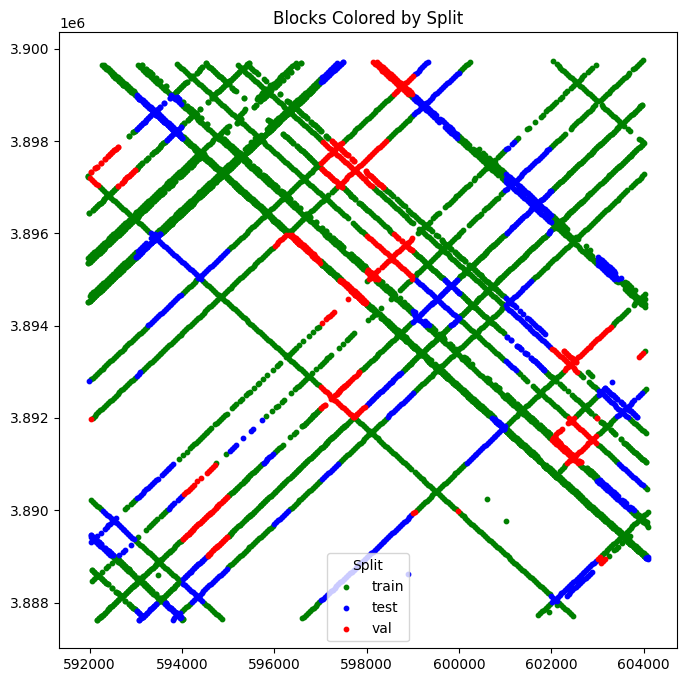

In [ ]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt

# Load CSV
csv_path = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/GEDI_target/GEDI_L2A_L2B_L1B_merged_11_3_25_with_blocks_splits.csv'
df = pd.read_csv(csv_path)

# Create geometry
geometry = [Point(xy) for xy in zip(df['x'], df['y'])]
gdf = gpd.GeoDataFrame(df, geometry=geometry)

# Define colors
split_colors = {'train': 'green', 'test': 'blue', 'val': 'red'}
gdf['color'] = gdf['split'].map(split_colors)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
for split_name, color in split_colors.items():
    gdf[gdf['split'] == split_name].plot(
        ax=ax, color=color, label=split_name, markersize=10
    )

plt.legend(title="Split")
plt.title("Blocks Colored by Split")
plt.show()


In [ ]:
!pip install contextily

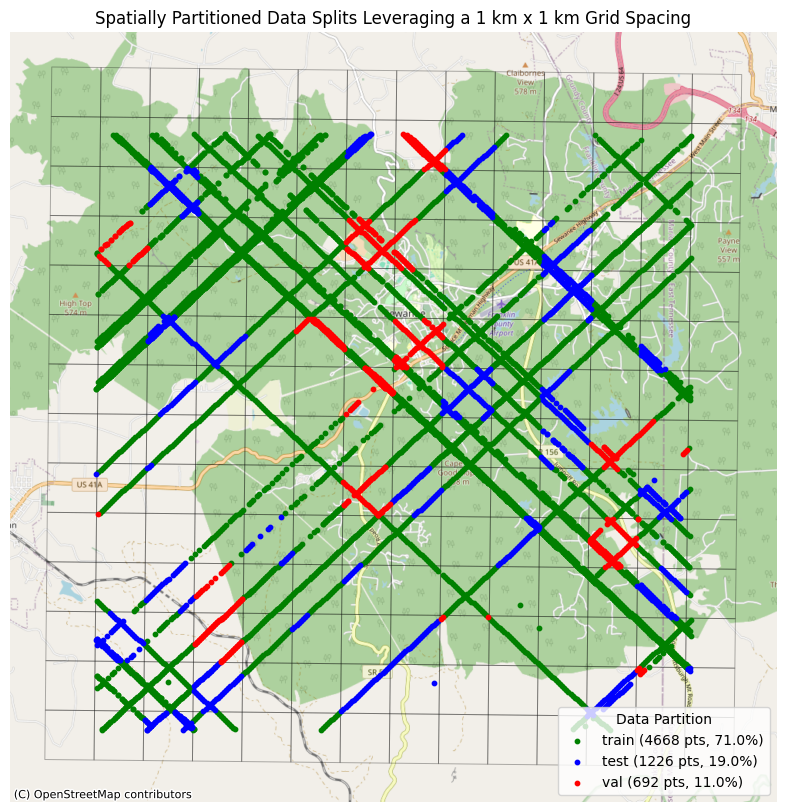

✅ Figure saved to: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/GEDI_target/GEDI_grid_Spatially_Partitioned_map.png


<Figure size 640x480 with 0 Axes>

In [ ]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, box
import matplotlib.pyplot as plt
import contextily as ctx

# Load CSV
output_path = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/GEDI_target/GEDI_L2A_L2B_L1B_merged_11_3_25_with_blocks_splits.csv'
df = pd.read_csv(output_path)

# Create GeoDataFrame for points
geometry = [Point(xy) for xy in zip(df['x'], df['y'])]
gdf_points = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:32616")  # UTM zone 16N

# Create 1 km x 1 km grid blocks
block_size_m = 1000
xmin, ymin, xmax, ymax = gdf_points.total_bounds

x_coords = list(range(int(xmin // block_size_m) * block_size_m, int(xmax // block_size_m + 2) * block_size_m, block_size_m))
y_coords = list(range(int(ymin // block_size_m) * block_size_m, int(ymax // block_size_m + 2) * block_size_m, block_size_m))

grid_polygons = []
for x in x_coords:
    for y in y_coords:
        grid_polygons.append({'minx': x, 'geometry': box(x, y, x + block_size_m, y + block_size_m)})

gdf_blocks = gpd.GeoDataFrame(grid_polygons, crs="EPSG:32616")

# Remove only the furthest-right column of blocks
max_x = gdf_blocks['minx'].max()
gdf_blocks = gdf_blocks[gdf_blocks['minx'] < max_x]

# Convert to Web Mercator for OSM
gdf_points_web = gdf_points.to_crs(epsg=3857)
gdf_blocks_web = gdf_blocks.to_crs(epsg=3857)

# Compute counts and proportions
split_counts = df['split'].value_counts()
total_points = len(df)
split_props = (split_counts / total_points).round(2)

# Prepare legend labels
legend_labels = {split: f"{split} ({split_counts[split]} pts, {split_props[split]*100:.1f}%)"
                 for split in split_counts.index}

# Define colors
split_colors = {'train': 'green', 'test': 'blue', 'val': 'red'}

# Plot
fig, ax = plt.subplots(figsize=(12, 10))

# Plot blocks (transparent)
gdf_blocks_web.plot(ax=ax, facecolor='none', edgecolor='black', alpha=0.3, linewidth=0.7)

# Plot points on top with custom legend labels
for split_name, color in split_colors.items():
    gdf_points_web[gdf_points_web['split'] == split_name].plot(
        ax=ax, color=color, markersize=10, label=legend_labels.get(split_name, split_name)
    )

# Add OSM basemap
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

# Legend bottom right
ax.legend(title="Data Partition", loc='lower right')

# Remove axes
ax.set_axis_off()
plt.title("Spatially Partitioned Data Splits Leveraging a 1 km x 1 km Grid Spacing")
plt.show()


# Save figure
save_path = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/GEDI_target/GEDI_grid_Spatially_Partitioned_map.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print("✅ Figure saved to:", save_path)


File Nomenclature

{*covariate*}_{*split*}_{*product_field*}_{*shot*}_{*row_ID*}{*block_id*}.tif

dem_train_L2B_gedi_2048187000123456_block_341_442.tif



In [ ]:
# Load CSV
csv_path = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/GEDI_target/GEDI_L2A_L2B_L1B_merged_11_3_25_with_blocks_splits.csv'
df = pd.read_csv(csv_path)
df

,beam,source_file,lat,lon,elev_lowestmode,digital_elevation_model,solar_elevation,sensitivity,degrade_flag,quality_flag,...,pavd_z_bin_9,stale_return_flag,pai_z_bin_4,x,y,block_x,block_y,block_id,row_ID,split
0,BEAM0101,118699863_GEDI02_A_2020196021509_O08987_02_T05...,35.214071,-85.989695,455.898773,470.743774,-18.850618,0.977285,0.0,1.0,...,NaN,NaN,NaN,591952.855432,3.897251e+06,591,3897,591_3897,1,train
1,BEAM0101,118699863_GEDI02_A_2020196021509_O08987_02_T05...,35.214767,-85.988777,459.104523,467.231506,-18.850683,0.990288,0.0,1.0,...,NaN,NaN,NaN,592035.619870,3.897329e+06,592,3897,592_3897,2,val
2,BEAM0101,118699863_GEDI02_A_2020196021509_O08987_02_T05...,35.215471,-85.987846,449.121246,455.059265,-18.850748,0.989432,0.0,1.0,...,NaN,NaN,NaN,592119.554656,3.897408e+06,592,3897,592_3897,3,val
3,BEAM0101,118699863_GEDI02_A_2020196021509_O08987_02_T05...,35.215807,-85.987407,470.780426,477.108856,-18.850777,0.990889,0.0,1.0,...,NaN,NaN,NaN,592159.115617,3.897445e+06,592,3897,592_3897,4,val
4,BEAM0101,118699863_GEDI02_A_2020196021509_O08987_02_T05...,35.216501,-85.986494,478.569794,489.838898,-18.850840,0.981278,0.0,1.0,...,NaN,NaN,NaN,592241.425190,3.897523e+06,592,3897,592_3897,5,val
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6581,NaN,NaN,35.145647,-85.858979,NaN,556.715759,43.667702,NaN,NaN,NaN,...,NaN,0.0,NaN,603937.567784,3.889791e+06,603,3889,603_3889,6582,train
6582,NaN,NaN,35.145297,-85.858518,NaN,548.169678,43.668106,NaN,NaN,NaN,...,NaN,0.0,NaN,603979.987245,3.889752e+06,603,3889,603_3889,6583,train
6583,NaN,NaN,35.144948,-85.858061,NaN,548.169678,43.668510,NaN,NaN,NaN,...,NaN,0.0,NaN,604022.095454,3.889714e+06,604,3889,604_3889,6584,train
6584,NaN,NaN,35.144597,-85.857598,NaN,552.613403,43.668919,NaN,NaN,NaN,...,NaN,0.0,NaN,604064.666627,3.889676e+06,604,3889,604_3889,6585,train


In [ ]:
import pandas as pd
import numpy as np

# Load CSV
csv_path = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/GEDI_target/GEDI_L2A_L2B_L1B_merged_11_3_25_with_blocks_splits.csv'
df = pd.read_csv(csv_path)

# Check basic info
print("Shape:", df.shape)
print("\nColumns with NaN values:")
print(df.isna().sum())

# Inspect rows with NaN in critical columns for GEE
critical_cols = ['lat', 'lon', 'block_id', 'split']
nan_rows = df[df[critical_cols].isna().any(axis=1)]
print(f"\nNumber of rows with NaN in {critical_cols}: {nan_rows.shape[0]}")
print("\nExample rows with NaN in critical columns:")
print(nan_rows.head(10))

# Check for infinite values (Earth Engine also rejects these)
inf_rows = df[np.isinf(df['lat']) | np.isinf(df['lon'])]
print(f"\nNumber of rows with infinite lat/lon: {inf_rows.shape[0]}")

# Quick fix suggestion: drop or fill NaNs
df_clean = df.dropna(subset=critical_cols)
print(f"\nShape after dropping rows with NaN in {critical_cols}: {df_clean.shape}")

# Optional: ensure correct types
df_clean['split'] = df_clean['split'].astype(str)
df_clean['block_id'] = df_clean['block_id'].astype(int)

print("\n✅ Data is ready for GEE export test.")


Shape: (6586, 135)

Columns with NaN values:
beam               3846
source_file        3846
lat                   0
lon                   0
elev_lowestmode    3846
                   ... 
block_x               0
block_y               0
block_id              0
row_ID                0
split                 0
Length: 135, dtype: int64

Number of rows with NaN in ['lat', 'lon', 'block_id', 'split']: 0

Example rows with NaN in critical columns:
Empty DataFrame
Columns: [beam, source_file, lat, lon, elev_lowestmode, digital_elevation_model, solar_elevation, sensitivity, degrade_flag, quality_flag, num_detectedmodes, rh, dem_diff, product_field, shot_number, cover_z_bin_21, pai_z_bin_5, pai_z_bin_23, pai_z_bin_8, pai_z_bin_18, pavd_z_bin_6, cover_z_bin_12, pai_z_bin_24, pai_z_bin_17, pavd_z_bin_1, pavd_z_bin_10, rx_energy, pavd_z_bin_11, pavd_z_bin_20, cover_z_bin_10, pai_z_bin_16, cover_z_bin_22, cover_z_bin_27, pavd_z_bin_28, pavd_z_bin_4, pai_z_bin_22, pavd_z_bin_19, pavd_z_bin_2, elevat

11/6

In [ ]:
# import pandas as pd

# GEDI_CSV = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/GEDI_target/GEDI_L2A_L2B_L1B_merged_11_3_25_with_blocks_splits.csv"

# # Load CSV
# df = pd.read_csv(GEDI_CSV)

# Filter for product_field == "GEDI_LSA"
df_filtered_GEDI_L2A = df_clean[df_clean["product_field"] == "GEDI_L2A"]



In [ ]:
# df = df_clean

In [ ]:
'GEDI_native_resolution_patches_32x32_11_6'

'GEDI_native_resolution_patches_32x32_11_6'

In [ ]:
import ee
import pandas as pd

# Initialize Earth Engine
# ee.Initialize()

# -----------------------------
# STEP 0 — Load CSV and clean
# -----------------------------
# csv_path = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/GEDI_target/GEDI_L2A_L2B_L1B_merged_11_3_25_with_blocks_splits.csv'
# df = pd.read_csv(csv_path)

# df = df_clean
df = df_filtered_GEDI_L2A

# Drop rows with NaN in critical columns
df = df.dropna(subset=['lat', 'lon', 'block_id', 'split', 'shot_number', 'product_field', 'row_ID'])
print("Initial rows:", len(df))

# -----------------------------
# STEP 1 — Subsample N points with preserved splits
# -----------------------------
N_total = 500  # total points to export

# Compute split ratios
split_ratios = df['split'].value_counts(normalize=True).to_dict()

# Sample points per split
df_sampled_list = []
for split_name, prop in split_ratios.items():
    df_split = df[df['split'] == split_name]
    n_split = int(round(N_total * prop))
    df_sampled_list.append(df_split.sample(n=n_split, random_state=42))

# Combine and shuffle
df_sampled = pd.concat(df_sampled_list).reset_index(drop=True)
df_sampled = df_sampled.sample(frac=1, random_state=42).reset_index(drop=True)

print("Sampled points per split:")
print(df_sampled['split'].value_counts())

# -----------------------------
# STEP 2 — Define covariates
# -----------------------------
covariates = {
    # "s1": {"image": ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/s1Ascending_2021"), "scale": 10},
    # "dem": {"image": ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/DEMindices_2021_7_17"), "scale": 30},
    # "hls": {"image": ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/HLS_2021"), "scale": 30},
    # "landsat": {"image": ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/LandsatComposite_2021"), "scale": 30},
    # "landsat_idx": {"image": ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/LandsatIndices_2021"), "scale": 30},
    # "tcap": {"image": ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/landsatTasseledCapIndices_2021"), "scale": 30},
    "s2": {"image": ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/S2Composite_2021"), "scale": 20},
    # "s2_idx": {"image": ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/S2Indices_2021"), "scale": 20}

}

# -----------------------------
# STEP 3 — Export setup
# -----------------------------
export_folder = 'GEDI_native_resolution_patches_32x32_11_6'
patch_pixels = 32  # 32x32 patch

# Convert sampled dataframe to Python list for safe client-side iteration
sampled_rows = df_sampled.to_dict(orient='records')

# -----------------------------
# STEP 4 — Submit export tasks
# -----------------------------
for cov_name, cov in covariates.items():
    img = cov["image"]
    scale = cov["scale"]

    for row in sampled_rows:
        # Create buffer for 32x32 pixels at native scale
        pt = ee.Geometry.Point([row['lon'], row['lat']])
        buffer_m = (patch_pixels / 2) * scale
        region = pt.buffer(buffer_m).bounds()

        # Exact filename convention
        fname = f"{cov_name}_{row['split']}_{row['product_field']}_{row['shot_number']}_{row['row_ID']}_block_{row['block_id']}"

        # Submit export task to Drive
        task = ee.batch.Export.image.toDrive(
            image=img,
            description=fname,
            folder=export_folder,
            fileNamePrefix=fname,
            region=region,
            scale=scale,
            crs="EPSG:32616",
            maxPixels=1e13
        )
        task.start()
        print(f"✅ Export task started: {fname}")

print("🎉 All export tasks submitted! You can safely close Colab; Earth Engine runs them server-side.")


Initial rows: 1868
Sampled points per split:
split
train    733
test     164
val      103
Name: count, dtype: int64
✅ Export task started: s1_train_GEDI_L2A_2022358084911_393_block_6003897
✅ Export task started: s1_test_GEDI_L2A_2022139064237_230_block_5933887
✅ Export task started: s1_test_GEDI_L2A_2022358084911_856_block_6013897
✅ Export task started: s1_train_GEDI_L2A_2022358084911_1243_block_5953890
✅ Export task started: s1_train_GEDI_L2A_2022358084911_1251_block_5963891
✅ Export task started: s1_train_GEDI_L2A_2022358084911_389_block_6003897
✅ Export task started: s1_train_GEDI_L2A_2021135083748_150_block_6003894
✅ Export task started: s1_train_GEDI_L2A_2021135083748_672_block_6033891
✅ Export task started: s1_test_GEDI_L2A_2022139064237_202_block_5923889
✅ Export task started: s1_train_GEDI_L2A_2021135083748_50_block_5953899
✅ Export task started: s1_test_GEDI_L2A_2022358084911_1278_block_5993894
✅ Export task started: s1_train_GEDI_L2A_2022358084911_1776_block_5993893
✅ Export 

KeyboardInterrupt: 

Use this block below if you hit the 3000 export limit, this will diff your export folder via file name and pick up hte export process

In [ ]:
import os
import ee
import pandas as pd

# Initialize EE
# ee.Initialize()

# --- Parameters ---
export_folder = "/content/drive/MyDrive/GEDI_native_resolution_patches_32x32_11_6"
N_total = 500  # total points to export

# Load your CSV of points
# csv_path = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/GEDI_target/GEDI_L2A_L2B_L1B_merged_11_3_25_with_blocks_splits.csv'
# df = pd.read_csv(csv_path)

df = df_clean

df = df.dropna(subset=['lat','lon','block_id','split','shot_number','product_field','row_ID'])

# --- STEP 1: Identify already exported Row IDs ---
existing_files = os.listdir(export_folder)
existing_row_ids = set()
for f in existing_files:
    # Assumes filenames include "_<row_ID>_block_" like: s1_train_GEDI_L2A_gedi_2048187000123456_block_341_442.tif
    try:
        row_id_part = f.split('_')[5]  # the 6th element in your filename format
        existing_row_ids.add(row_id_part)
    except IndexError:
        continue

print(f"Found {len(existing_row_ids)} already exported Row IDs.")

# --- STEP 2: Filter points that still need exporting ---
df_remaining = df[~df['row_ID'].astype(str).isin(existing_row_ids)]
print(f"{len(df_remaining)} points remaining to export.")

# --- STEP 3: Subsample to N_total points with split proportions ---
split_counts = df_remaining['split'].value_counts(normalize=True)
df_sampled = df_remaining.groupby('split', group_keys=False).apply(
    lambda g: g.sample(int(N_total * split_counts[g.name]), random_state=42)
).reset_index(drop=True)

print("Sampled points per split:")
print(df_sampled['split'].value_counts())

# --- STEP 4: Convert to EE FeatureCollection ---
features = []
for _, row in df_sampled.iterrows():
    pt = ee.Geometry.Point([row['lon'], row['lat']])
    feat = ee.Feature(pt, {
        'shot': str(int(row['shot_number'])),
        'block_id': str(row['block_id']),
        'split': str(row['split']),
        'product_field': str(row['product_field']),
        'row_ID': str(row['row_ID'])
    })
    features.append(feat)
gedi_fc = ee.FeatureCollection(features)
print(f"✅ FeatureCollection created with {gedi_fc.size().getInfo()} features.")

# --- EO datasets ---
covariates = {
    "s1": {"image": ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/s1Ascending_2021"), "scale": 10},
    "dem": {"image": ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/DEMindices_2021_7_17"), "scale": 30},
    "hls": {"image": ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/HLS_2021"), "scale": 30},
    "landsat": {"image": ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/LandsatComposite_2021"), "scale": 30},
    "landsat_idx": {"image": ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/LandsatIndices_2021"), "scale": 30},
    "tcap": {"image": ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/landsatTasseledCapIndices_2021"), "scale": 30},
    "s2": {"image": ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/S2Composite_2021"), "scale": 20},
    "s2_idx": {"image": ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/S2Indices_2021"), "scale": 20}
}

# --- STEP 5: Export function ---
patch_pixels = 32

def export_for_covariate(cov_name, img, scale):
    lst = gedi_fc.toList(gedi_fc.size())
    n = gedi_fc.size().getInfo()
    for i in range(n):
        f = ee.Feature(lst.get(i))
        shot = f.get('shot').getInfo()
        block = f.get('block_id').getInfo()
        split = f.get('split').getInfo()
        product = f.get('product_field').getInfo()
        row_id = f.get('row_ID').getInfo()
        region = f.geometry().buffer((patch_pixels/2)*scale).bounds()
        fname = f"{cov_name}_{split}_{product}_{shot}_{row_id}_block_{block}"

        # Only export if file does not exist
        if not os.path.exists(os.path.join(export_folder, fname + ".tif")):
            task = ee.batch.Export.image.toDrive(
                image=img,
                description=fname,
                folder=export_folder,
                fileNamePrefix=fname,
                region=region,
                scale=scale,
                crs="EPSG:32616",
                maxPixels=1e13
            )
            task.start()
            print(f"🚀 Exporting: {fname}")
        else:
            print(f"✅ Already exists: {fname}")

# --- STEP 6: Run exports ---
for cov_name, d in covariates.items():
    export_for_covariate(cov_name, d["image"], d["scale"])

print("🎉 All export tasks submitted (only missing files).")


Found 788 already exported Row IDs.
6086 points remaining to export.
Sampled points per split:
split
train    354
test      93
val       52
Name: count, dtype: int64
✅ FeatureCollection created with 499 features.
🚀 Exporting: s1_test_GEDI_L1B_35301100300415568_4536_block_5943895
🚀 Exporting: s1_test_GEDI_L1B_189911100200255699_5417_block_6023888
🚀 Exporting: s1_test_GEDI_L1B_24260500200098510_2795_block_5963889
🚀 Exporting: s1_test_GEDI_L1B_35300500300415545_3019_block_5933898
🚀 Exporting: s1_test_GEDI_L1B_24261100200098564_4394_block_6003891
🚀 Exporting: s1_test_GEDI_L2A_2021135083748_632_block_6013893
🚀 Exporting: s1_test_GEDI_L1B_55140500300414757_3362_block_6013896
🚀 Exporting: s1_test_GEDI_L2A_2022139064237_231_block_5933887
🚀 Exporting: s1_test_GEDI_L1B_331701100300207074_6466_block_5993894
🚀 Exporting: s1_test_GEDI_L1B_55141100300414679_4955_block_6033892
🚀 Exporting: s1_test_GEDI_L1B_24261100200098580_4410_block_6003891
🚀 Exporting: s1_test_GEDI_L2A_2022358084911_271_block_5933

EEException: Too many tasks already in the queue (3000, limit 3000).

In [ ]:
import os
from collections import Counter

folder_path = "/content/drive/MyDrive/GEDI_native_resolution_patches_32x32_11_6"

# List all files in the folder
all_files = [f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))]

# Count total files
total_files = len(all_files)
print(f"Total files: {total_files}")

# Check for duplicates
file_counts = Counter(all_files)
duplicates = [file for file, count in file_counts.items() if count > 1]

if duplicates:
    print(f"Duplicated file names ({len(duplicates)}):")
    for file in duplicates:
        print(file)
else:
    print("No duplicated file names found.")


Total files: 3007
No duplicated file names found.


In [ ]:
# Create the destination folder if it doesn't exist
!mkdir -p "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/data_32_32_patches_11_4_25"

# Move all files from the new export folder to the destination
!mv "/content/drive/MyDrive/GEDI_native_resolution_patches_32x32_11_6/"* "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/data_32_32_patches_11_4_25/"


In [9]:
import os
import shutil

src = "/content/drive/MyDrive/GEDI_native_resolution_patches_32x32_11_6"
dst = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/data_32_32_patches_11_4_25"

# Make sure destination exists
os.makedirs(dst, exist_ok=True)

moved = 0
skipped = 0

for filename in os.listdir(src):
    src_path = os.path.join(src, filename)
    dst_path = os.path.join(dst, filename)

    # Ensure it's a file (skip directories)
    if not os.path.isfile(src_path):
        continue

    if not os.path.exists(dst_path):
        shutil.move(src_path, dst_path)
        print(f"Moved: {filename}")
        moved += 1
    else:
        print(f"Skipped duplicate: {filename}")
        skipped += 1

print("\nDone!")
print(f"Moved files: {moved}")
print(f"Skipped duplicates: {skipped}")


Moved: s2_idx_train_GEDI_L2A_2020196021509_495_block_5953899.tif
Moved: s2_idx_train_GEDI_L2A_2021135083748_1617_block_6013891.tif
Moved: s2_idx_train_GEDI_L2A_2022358084911_1766_block_5983893.tif
Moved: s2_idx_test_GEDI_L2A_2022358084911_856_block_6013897.tif
Moved: s2_idx_test_GEDI_L2A_2022358084911_244_block_5923889.tif
Moved: s2_idx_test_GEDI_L2A_2020196021509_21_block_5933898.tif
Moved: s2_idx_train_GEDI_L2A_2022358084911_1344_block_6023897.tif
Moved: s2_idx_train_GEDI_L2A_2020196021509_1445_block_5953897.tif
Moved: s2_idx_val_GEDI_L2A_2022358084911_1221_block_5943889.tif
Moved: s2_idx_train_GEDI_L2A_2022358084911_1215_block_5933889.tif
Moved: s2_idx_train_GEDI_L2A_2021135083748_1613_block_6013891.tif
Moved: s2_idx_train_GEDI_L2A_2021135083748_134_block_6003895.tif
Moved: s2_idx_train_GEDI_L2A_2021135083748_71_block_5963898.tif
Moved: s2_idx_test_GEDI_L2A_2022139064237_230_block_5933887.tif
Moved: s2_idx_test_GEDI_L2A_2022139064237_204_block_5923889.tif
Moved: s2_idx_val_GEDI_L2A_

before 11/6

# Inference prep

In [ ]:
# import ee
# import pandas as pd
# import time

# # # Initialize EE
# # try:
# #     ee.Initialize()
# # except:
# #     ee.Authenticate()
# #     ee.Initialize()

# # ================================
# # USER SETTINGS
# # ================================

# PATCH_SIZE = 32      # 32×32 pixels
# OVERLAP = 0.25       # 0.0 = no overlap, 0.5 = 50% overlap
# EXPORT_FOLDER = export_folder
# MAX_TASKS = 250      # Stay under quota

# # ================================
# # LOAD YOUR CSV OF TARGET POINTS
# # ================================
# df = df_filtered_GEDI_L2A.copy()

# df = df.dropna(subset=["lat", "lon"])
# print("Rows:", len(df))

# # Convert to dict for iteration
# rows = df.to_dict(orient="records")

# # ================================
# # DEFINE EO DATASETS FOR 2024
# # ================================
# covariates = {
#     "s1":          {"image": ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/s1Ascending_2024"), "scale": 10},
#     # "dem":         {"image": ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/DEMindices_2024"), "scale": 30},
#     # "hls":         {"image": ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/HLS_2024"), "scale": 30},
#     # "landsat":     {"image": ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/LandsatComposite_2024"), "scale": 30},
#     # "landsat_idx": {"image": ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/LandsatIndices_2024"), "scale": 30},
#     # "tcap":        {"image": ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/landsatTasseledCapIndices_2024"), "scale": 30},
#     # "s2":          {"image": ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/S2Composite_2024"), "scale": 20},
#     # "s2_idx":      {"image": ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/S2Indices_2024"), "scale": 20}
# }

# # ================================
# # FUNCTION: SAFELY EXPORT A PATCH
# # ================================
# def start_export(img, region, scale, fname):
#     """Safely starts an EE export task."""
#     task = ee.batch.Export.image.toDrive(
#         image=img,
#         description=fname,
#         folder=EXPORT_FOLDER,
#         fileNamePrefix=fname,
#         region=region,
#         scale=scale,
#         crs="EPSG:32616",
#         maxPixels=1e13
#     )
#     task.start()
#     return task


# # ================================
# # EXPORT PATCHES
# # ================================
# task_count = 0

# for cov_name, cov in covariates.items():

#     img = cov["image"]
#     scale = cov["scale"]

#     window_m = PATCH_SIZE * scale
#     stride = window_m * (1 - OVERLAP)  # overlap handling

#     for r in rows:

#         pt = ee.Geometry.Point([r["lon"], r["lat"]])

#         # Create a valid bounding box
#         try:
#             footprint = img.geometry()
#             if not footprint.intersects(pt, ee.ErrorMargin(1)).getInfo():
#                 print(f"⚠ Skipping point not in image footprint: {r['row_ID']}")
#                 continue
#         except:
#             continue

#         # Sliding window grid
#         for dx in [-0.5 * stride, 0.5 * stride]:
#             for dy in [-0.5 * stride, 0.5 * stride]:

#                 shifted_pt = ee.Geometry.Point([
#                     r["lon"] + dx / 111320,
#                     r["lat"] + dy / 110540
#                 ])

#                 region = shifted_pt.buffer(window_m / 2).bounds()

#                 fname = f"{cov_name}_patch_{r['row_ID']}_{int(time.time())}"

#                 try:
#                     start_export(img, region, scale, fname)
#                     task_count += 1
#                     print(f"📤 Started: {fname}")
#                 except Exception as e:
#                     print(f"❌ Export failed for {fname}: {e}")

#                 # Prevent EE from blocking excessive tasks
#                 if task_count >= MAX_TASKS:
#                     print("⚠ Reached task limit — stopping to avoid quota errors.")
#                     break

#             if task_count >= MAX_TASKS:
#                 break

#         if task_count >= MAX_TASKS:
#             break

#     if task_count >= MAX_TASKS:
#         break

# print(f"🎉 Submitted {task_count} export tasks.")


Rows: 1868
📤 Started: s1_patch_1_1763999981
📤 Started: s1_patch_1_1763999982
📤 Started: s1_patch_1_1763999982
📤 Started: s1_patch_1_1763999982
📤 Started: s1_patch_2_1763999982
📤 Started: s1_patch_2_1763999983
📤 Started: s1_patch_2_1763999983
📤 Started: s1_patch_2_1763999983
📤 Started: s1_patch_3_1763999983
📤 Started: s1_patch_3_1763999984
📤 Started: s1_patch_3_1763999984
📤 Started: s1_patch_3_1763999984
📤 Started: s1_patch_4_1763999984
📤 Started: s1_patch_4_1763999985
📤 Started: s1_patch_4_1763999985
📤 Started: s1_patch_4_1763999985
📤 Started: s1_patch_5_1763999985
📤 Started: s1_patch_5_1763999986
📤 Started: s1_patch_5_1763999986
📤 Started: s1_patch_5_1763999986
📤 Started: s1_patch_6_1763999987
📤 Started: s1_patch_6_1763999987
📤 Started: s1_patch_6_1763999987
📤 Started: s1_patch_6_1763999987
📤 Started: s1_patch_7_1763999988
📤 Started: s1_patch_7_1763999988
📤 Started: s1_patch_7_1763999988
📤 Started: s1_patch_7_1763999988
📤 Started: s1_patch_8_1763999989
📤 Started: s1_patch_8_1763999989

In [ ]:
# # ============================================
# #     FULL SURFACE PATCHING FOR 2024 EO
# #     Multi-modality patch extraction
# # ============================================

# import ee
# import time


# print("ROI loaded.")


# # =========================================================
# # 2 — EO MODALITIES (2024)
# # =========================================================
# covariates = {
#     "s1":          {"image": ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/s1Ascending_2024"), "scale": 10},
# #     "dem":         {"image": ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/DEMindices_2024"), "scale": 30},
# #     "hls":         {"image": ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/HLS_2024"), "scale": 30},
# #     "landsat":     {"image": ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/LandsatComposite_2024"), "scale": 30},
# #     "landsat_idx": {"image": ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/LandsatIndices_2024"), "scale": 30},
# #     "tcap":        {"image": ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/landsatTasseledCapIndices_2024"), "scale": 30},
# #     "s2":          {"image": ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/S2Composite_2024"), "scale": 20},
# #     "s2_idx":      {"image": ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/S2Indices_2024"), "scale": 20},
# # }

# # =========================================================
# # 3 — PATCH SETTINGS
# # =========================================================
# PATCH_SIZE = 32     # pixels
# OVERLAP    = 4     # pixels (set 0 for non-overlapping)
# EXPORT_FOLDER = "EO_Inference_2024"
# MAX_TASKS = 100     # do not exceed EE quota
# submitted = 0

# # =========================================================
# # 4 — FUNCTION: create mesh grid of patch centers
# # =========================================================
# def generate_centers(roi, scale, patch_size, overlap):
#     """Generate a grid of patch center points across ROI."""
#     step = patch_size - overlap
#     pixel_m = scale
#     stride_m = step * pixel_m
#     half_m = (patch_size / 2) * pixel_m

#     bounds = roi.bounds().coordinates().get(0)
#     coords = bounds.getInfo()

#     xmin, ymin = coords[0]
#     xmax, ymax = coords[2]

#     xs = []
#     ys = []

#     cur_x = xmin
#     while cur_x < xmax:
#         cur_y = ymin
#         while cur_y < ymax:
#             xs.append(cur_x)
#             ys.append(cur_y)
#             cur_y += (stride_m / 111320.0)
#         cur_x += (stride_m / 111320.0)

#     points = [ee.Geometry.Point([x, y]) for x, y in zip(xs, ys)]
#     return points, half_m


# # =========================================================
# # 5 — CHECK RUNNING TASKS
# # =========================================================
# def active_tasks():
#     return sum([t.active() for t in ee.batch.Task.list()])


# # =========================================================
# # 6 — EXPORT LOOP
# # =========================================================
# for cov_name, item in covariates.items():
#     img = item["image"]
#     scale = item["scale"]

#     print(f"\n====================================")
#     print(f"  Starting modality: {cov_name}")
#     print(f"====================================")

#     # compute grid of patch centers
#     centers, half_m = generate_centers(
#         ROI, scale, PATCH_SIZE, OVERLAP
#     )

#     print(f" → Total patches: {len(centers)}")

#     # Loop over patch centers
#     for idx, pt in enumerate(centers):

#         # Clip region
#         region = pt.buffer(half_m).bounds()

#         # Throttle tasks
#         while active_tasks() >= MAX_TASKS:
#             print("⏳ Waiting for available task slots…")
#             time.sleep(20)

#         fname = f"{cov_name}_patch_{idx}"

#         # Launch task
#         task = ee.batch.Export.image.toDrive(
#             image=img,
#             description=fname,
#             folder=EXPORT_FOLDER,
#             fileNamePrefix=fname,
#             region=region,
#             scale=scale,
#             crs="EPSG:32616",
#             maxPixels=1e13
#         )
#         task.start()
#         submitted += 1

#         print(f"📤 Started: {fname}  ({submitted} total)")

# print("\n🎉 ALL TASKS SUBMITTED SUCCESSFULLY 🎉")
# print(f"Total tasks started: {submitted}")
